# Clustering Validation: XGBoost Classification

This notebook validates the previously found clusters (`module_1_clustering_ipynb`) by using them as target variable in a multi-class classification XGBoost Model. 

In [6]:
#Load packages 
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.metrics import accuracy_score, recall_score, precision_score, classification_report
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier
from sklearn.model_selection import GroupKFold

In [7]:
#load data 
df = pd.read_csv("../../data/final_datasets/df_clusters_milieuschutz.csv", dtype={"plr_id": str})
df.head(2)

,plr_id,plr_name,bez,re_miete_niveau,re_miete_trend,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_dichte_all,soc_young_to_middle_adult_share_2025,...,cluster_3k,cluster_4k,ms_portion,ms_over50,ms_over60,ms_over70,ms_over80,ms_over90,oof_prob,on_watchlist
0,01100101,Stülerstraße,01 - Mitte,22.7,2.142,3.050847,3890.584913,-0.326098,10.653753,0.460,...,2,1,0.0,0,0,0,0,0,0.005072,False
1,01100102,Großer Tiergarten,01 - Mitte,20.3,1.059,4.557180,3440.019389,-0.426678,24.075666,0.479,...,2,1,0.0,0,0,0,0,0,0.445204,False


In [8]:
#delete irrelevant columns
# keep id vars + all feature columns (re_ / soc_ / com_)
id_vars = ["plr_id", "plr_name", "bez","cluster_4k"]
keep = id_vars + [c for c in df.columns if c.startswith(("re_", "soc_", "com_"))]
df = df[keep]
df.head(2)

,plr_id,plr_name,bez,cluster_4k,re_miete_niveau,re_miete_trend,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_dichte_all,...,com_share_min_30y_slope,com_share_min_40y_slope,com_share_solo_slope,com_share_10plus_slope,com_gastro_share_slope,com_entry_rate_slope,com_exit_rate_slope,com_n_gastro,re_altbau_share,re_neubau_share
0,01100101,Stülerstraße,01 - Mitte,1,22.7,2.142,3.050847,3890.584913,-0.326098,10.653753,...,0.001367,-0.000276,0.024083,0.002754,0.003153,-0.00280,0.001395,13.000000,0.118160,0.102663
1,01100102,Großer Tiergarten,01 - Mitte,1,20.3,1.059,4.557180,3440.019389,-0.426678,24.075666,...,0.003015,0.001063,0.028592,0.002506,0.004856,-0.00093,-0.000664,129.333333,0.228719,0.297506


## XGBoost: Simple Train-Test Split

### Train-Test Split and Imputation

In [9]:
# define features and y
id_cols   = ["plr_id", "plr_name", "bez"]
non_feat  = id_cols + ["cluster_4k"]
feat_cols = [c for c in df.columns if c not in non_feat]

X = df[feat_cols]
y = df["cluster_4k"]

print(len(feat_cols), "Features | y-Spread:", y.value_counts().to_dict())

# split on raw data, stratified by cluster
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y)

# fit imputer on train set only and transform test set 
imputer = KNNImputer(n_neighbors=5)
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train),
                           columns=feat_cols, index=X_train.index)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),
                           columns=feat_cols, index=X_test.index)

print("Train:", X_train_imp.shape, "| Test:", X_test_imp.shape)
print("NaN after Imputation:", int(X_train_imp.isna().sum().sum()),
      int(X_test_imp.isna().sum().sum()))

42 Features | y-Spread: {0: 150, 2: 145, 3: 142, 1: 90}
Train: (368, 42) | Test: (159, 42)
NaN after Imputation: 0 0


### Fit XGBoost Model

In [10]:
# Set up XGB Classifier (basic version)
model = XGBClassifier(
    objective="multi:softprob",      # 4 Klassen statt binär
    num_class=4,
    eval_metric="mlogloss",          # passende Metrik für Multiklasse
    tree_method="hist",
    random_state=0,

    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,                     # bei 527 Zeilen flacher als 6
    subsample=0.8,
    colsample_bytree=0.8,
)

model.fit(X_train_imp, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

### Classification Report

In [11]:
y_pred = model.predict(X_test_imp)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}\n")

print(classification_report(y_test, y_pred))

Accuracy: 0.925

              precision    recall  f1-score   support

           0       0.91      0.89      0.90        45
           1       0.96      0.81      0.88        27
           2       0.93      0.98      0.96        44
           3       0.91      0.98      0.94        43

    accuracy                           0.92       159
   macro avg       0.93      0.91      0.92       159
weighted avg       0.93      0.92      0.92       159



### Confusion Matrix

In [12]:
print("Confusion matrix (Rows=true, Cols=predicted):")
print(pd.DataFrame(confusion_matrix(y_test, y_pred),
      index=["true_0","true_1","true_2","true_3"],
      columns=["pred_0","pred_1","pred_2","pred_3"]))

Confusion matrix (Rows=true, Cols=predicted):
        pred_0  pred_1  pred_2  pred_3
true_0      40       1       2       2
true_1       4      22       0       1
true_2       0       0      43       1
true_3       0       0       1      42


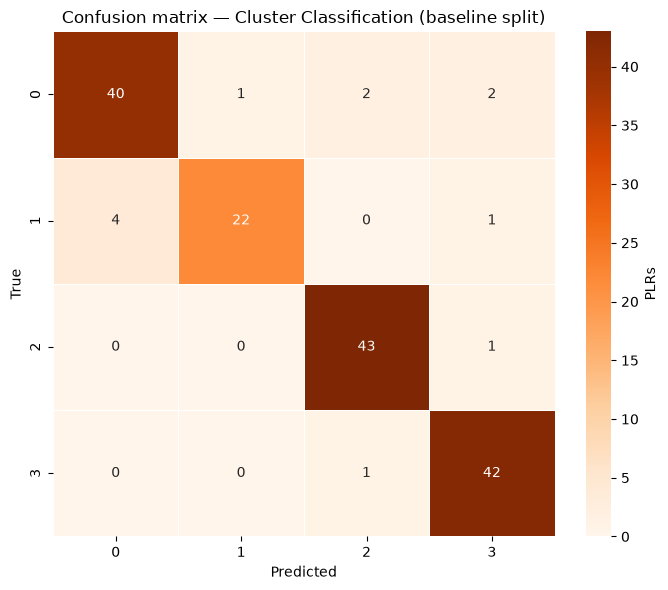

In [21]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            linewidths=0.5, linecolor="white",
            cbar_kws={"label": "PLRs"}, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix — Cluster Classification (baseline split)")
plt.tight_layout(); plt.show()

## XGBoost: GroupKFold 

The PLRs are spatially structured: neighbouring areas within the same district (Bezirk) tend to resemble one another (spatial autocorrelation). Under a standard train-test split or ordinary k-fold, some PLRs of a district land in the training set and others in the test set. The model can then recognise a test PLR through its trained neighbours rather than by genuinely generalising — a form of spatial leakage that inflates the apparent performance.

GroupKFold prevents this by keeping all PLRs of a district together in the same fold: when a district is in the test set, none of its PLRs were seen during training. The model must therefore predict each area's cluster type from other districts, which tests true generalisation to unseen areas. Comparing the GroupKFold result against the baseline split quantifies how much of the baseline accuracy rested on spatial proximity rather than on genuinely transferable structure.

### Fit XGBoost Model

In [22]:
# Features and y
X = df[feat_cols] 
y = df["cluster_4k"].astype(int)
groups = df["bez"]

gkf = GroupKFold(n_splits=5)
accs, all_true, all_pred = [], [], []

for fold, (tr, te) in enumerate(gkf.split(X, y, groups)):
    X_tr, X_te = X.iloc[tr], X.iloc[te]
    y_tr, y_te = y.iloc[tr], y.iloc[te]

    # Impute: only on train folds
    imp = KNNImputer(n_neighbors=5)
    X_tr_imp = pd.DataFrame(imp.fit_transform(X_tr), columns=feat_cols, index=X_tr.index)
    X_te_imp = pd.DataFrame(imp.transform(X_te),     columns=feat_cols, index=X_te.index)

    model = XGBClassifier(
        objective="multi:softprob", num_class=4,
        eval_metric="mlogloss", tree_method="hist", random_state=42,
        n_estimators=400, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8)
    model.fit(X_tr_imp, y_tr)

    pred = model.predict(X_te_imp)
    acc = accuracy_score(y_te, pred)
    accs.append(acc)
    all_true.extend(y_te); all_pred.extend(pred)
    print(f"Fold {fold+1}: acc = {acc:.3f}  | test bez: {list(groups.iloc[te].unique())}")

Fold 1: acc = 0.906  | test bez: ['03 - Pankow', '10 - Marzahn-Hellersdorf']
Fold 2: acc = 0.870  | test bez: ['04 - Charlottenburg-Wilmersdorf', '11 - Lichtenberg']
Fold 3: acc = 0.856  | test bez: ['01 - Mitte', '09 - Treptow-Köpenick', '12 - Reinickendorf']
Fold 4: acc = 0.912  | test bez: ['05 - Spandau', '07 - Tempelhof-Schöneberg']
Fold 5: acc = 0.902  | test bez: ['02 - Friedrichshain-Kreuzberg', '06 - Steglitz-Zehlendorf', '08 - Neukölln']


All folds have a high prediction accuracy, which is a good sign regarding the robustness of the clusters. Under GroupKFold by district, accuracy remains stable across folds despite very different district compositions (0.86–0.91), confirming that the four-cluster typology is consistently learnable across all parts of the city — strong evidence that the clusters are coherent and not artefacts of spatial autocorrelation. With only 12 districts, one might have expected stronger fluctuations — that they don't appear speaks for very stable clusters.
The slightly lowest fold (Fold 3, 0.856) contains Mitte — plausible, since Mitte has the densest inner-city areas, where City core and City ring lie closest together (the boundary blurring already visible in the baseline confusion matrix).

### Classification Report

In [23]:
print(f"\nMean accuracy: {np.mean(accs):.3f} (±{np.std(accs):.3f})")
print(f"Baseline (simple Train-Test-Split):  0.925\n")

print(classification_report(all_true, all_pred))


Mean accuracy: 0.889 (±0.022)
Baseline (simple Train-Test-Split):  0.925

              precision    recall  f1-score   support

           0       0.91      0.95      0.93       150
           1       0.86      0.80      0.83        90
           2       0.90      0.90      0.90       145
           3       0.87      0.87      0.87       142

    accuracy                           0.89       527
   macro avg       0.88      0.88      0.88       527
weighted avg       0.89      0.89      0.89       527



### Confusion Matrix

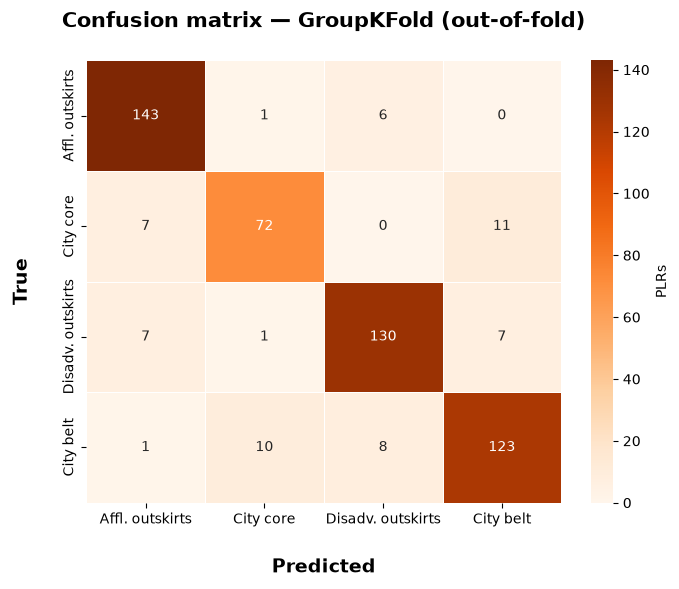

In [ ]:
labels = [0, 1, 2, 3]
names = ["Affl. outskirts", "City core", "Disadv. outskirts", "City belt"]

cm = confusion_matrix(all_true, all_pred, labels=labels)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=names, yticklabels=names,
            linewidths=0.5, linecolor="white", cbar_kws={"label": "PLRs"}, ax=ax)
ax.set_xlabel("\nPredicted", fontsize=14, fontweight="bold")
ax.set_ylabel("True\n", fontsize=14, fontweight="bold")
ax.set_title("Confusion matrix — GroupKFold (out-of-fold)\n", fontsize=15, fontweight="bold")
plt.tight_layout();
#fig.savefig("../../plots/presentation/CM_XGB_KFold.png", dpi=300, bbox_inches="tight")
plt.show()

All four clusters are recovered with strong diagonal dominance (out-of-fold), confirming that the typology is learnable across unseen districts rather than an artefact of spatial proximity. The only notable confusion is between Clusters (1) (3) — 11 1-PLRs predicted as 3-PLRs, 10 the reverse — exactly the boundary blurring expected between the two inner-city types formed by the core split.